# 🛍️ Customer Segmentation Analysis using RFM
---

## 📜 The Business Story

Imagine you run the marketing team for a retail company with **2,240 customers**.

Every month you send same promotional emails to every customer - loyal customers who buys every week, customers who haven't visited in a year, and everyone in between. 
The Result? Wasted Marketing budget, low conversions, and frustated customers getting irrelevant offers.

**The question we are trying to answer:**
>*" Who are our customers really -- and what's the best way to reach each group?"*

---

## 🎯 Project Goal

Use the **RFM (Recency, Frequency, Monetary)** framework to:
1. Segment customers based on their actual purchasing behaviour.
2. Understand which marketing campaign work for which group.
3. Give the marketing team clear, numbers-backed recommendations.

---



# 🗃️ About the Dataset

This is the real company CRM dataset from a retail company.
🌐 Source: [Kaggle — Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

**Column Guide -  what does each column actually means?**

| Column  | Plain English |
|---------|---------------|
| Recency |  Days since customer last made a purchase (lower = bought more recently) |
| MntWines, MntFruits, etc. | Amount Spent(in USD) on each product category over 2 years |
| NumWebPurchases, NumStorePurchases, etc. | How many times customers bought through each channel |
| AcceptedCmp1, AcceptedCmp2, etc. | Did the customer convert on that campaign? 1 = Yes (they recieved the offer AND made a purchase, 0 = No) |
| Response | Did they convert on the most recent campaign? |
| Dt_Customer | The date they first became a customer |
| Year_Birth | Used to calculate customer's age |

---

## 🧾 Campaign Index - what each campaign was?

| Campaign ID | Campaign Name | What it was |
|-------------|---------------|-------------|
| AcceptedCmp1 | Reactivation Drive | Re-engagemnt offers sent to lapsed customers |
| AcceptedCmp2 | New Arrivals Push | Promoted new product lines via email/catalolgue |
| AcceptedCmp3 | Seasonal Promotion | Time-limited discounts across all categories |
| AcceptedCmp4 | Loyalty Reward | Exclusive deals for repeat buyers |
| AcceptedCmp5 | Premium Upsell | Premium product bundles for high spenders |

> 📖 **Key Definition:** A `1` in a campaign column means that the **customer receieved the offer and made a purchase as a result** -- this is a conversion event. 
Not just a click or open.

---

## 📥 1. Import Libraries & Load Data

In [2]:
# Import everything we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# set a clean visual style
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [3]:
# Load the dataset
customer_df = pd.read_csv("E:\marketing_campaign.csv", delimiter='\t')
print('-' *50)
print("✅ Data loaded successfully!")

print(f"Data Loaded: {customer_df.shape[0]:,} rows * {customer_df.shape[1]} columns") 
print('-' *50)
customer_df.head(3)

--------------------------------------------------
✅ Data loaded successfully!
Data Loaded: 2,240 rows * 29 columns
--------------------------------------------------


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0


---
## 🧹 2. Clean & Prepare the Data

> Before any analysis we need to check the data quality -- Bad data = Bad Insights

In [4]:
# Check data types and non-null values
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
# Quick stats on all numeric columns
customer_df.describe().round(1)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.0,2240.0,2216.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,...,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0,2240.0
mean,5592.2,1968.8,52247.3,0.4,0.5,49.1,303.9,26.3,167.0,37.5,...,5.3,0.1,0.1,0.1,0.1,0.0,0.0,3.0,11.0,0.1
std,3246.7,12.0,25173.1,0.5,0.5,29.0,336.6,39.8,225.7,54.6,...,2.4,0.3,0.3,0.3,0.2,0.1,0.1,0.0,0.0,0.4
min,0.0,1893.0,1730.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
25%,2828.2,1959.0,35303.0,0.0,0.0,24.0,23.8,1.0,16.0,3.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
50%,5458.5,1970.0,51381.5,0.0,0.0,49.0,173.5,8.0,67.0,12.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
75%,8427.8,1977.0,68522.0,1.0,1.0,74.0,504.2,33.0,232.0,50.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
max,11191.0,1996.0,666666.0,2.0,2.0,99.0,1493.0,199.0,1725.0,259.0,...,20.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,11.0,1.0


In [6]:
# Percentage of null values in each column
missing_pct = (customer_df.isnull().sum()/ customer_df.shape[0] *100).round(1)
print("---- Missing values (%) ----")
print(missing_pct[missing_pct > 0])

---- Missing values (%) ----
Income    1.1
dtype: float64


In [7]:
# Income has ~1% nulls — safe to drop since it's a tiny fraction
customer_df = customer_df.dropna()
print(f"\nAfter dropping nulls: {len(customer_df):,} customers remain")


After dropping nulls: 2,216 customers remain


In [8]:
# Check for duplicate customers
duplicate_customers = customer_df.duplicated().sum()
print(f"Duplicate Customers: {duplicate_customers}")

Duplicate Customers: 0


In [9]:
# Income column has outlier, max income seems too large
# check income column for outliers
from scipy import stats

z_score = np.abs(stats.zscore(customer_df['Income']))

threshold = 5

customer_df[z_score > threshold]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


Text(0.5, 1.0, 'Income Distribution')

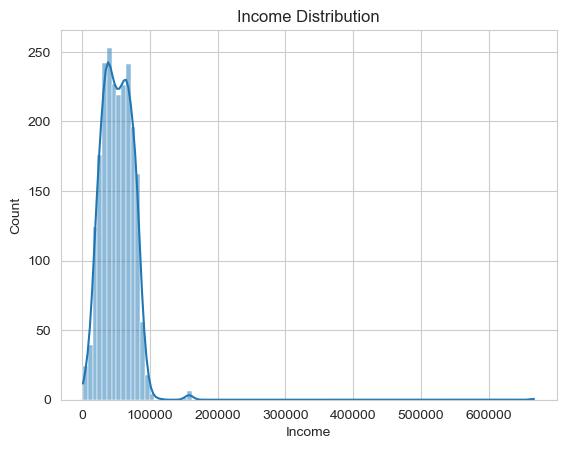

In [10]:
# plot the income distribution
sns.histplot(customer_df['Income'],kde= True)
plt.title("Income Distribution")

In [11]:
# one Income value is too large ($666666),it is 24 standard deviation away from the mean Income, remove it from the data
customer_df = customer_df[z_score < threshold]
customer_df.shape

(2215, 29)

In [12]:
# Remove Implausible ages
customer_df['Age'] = 2024 - customer_df['Year_Birth']

print(f"Age Range : {customer_df['Age'].min(), customer_df['Age'].max()}")

# Anyone over 90 is likely a data error
customer_df = customer_df[customer_df['Age'] <= 90]
print(f"After age filter : {customer_df.shape[0]} customers")

Age Range : (28, 131)
After age filter : 2212 customers


---

## ⚙️ Step 3: Feature Engineering
> Creating new columns which will be more useful than the raw data alone

In [13]:
# Total Spending across all product categories
customer_df['Total_Spent'] = (customer_df['MntWines'] 
                                 + customer_df['MntFruits'] 
                                 + customer_df['MntMeatProducts'] 
                                 + customer_df['MntFishProducts'] 
                                 + customer_df['MntSweetProducts']
                                 + customer_df['MntGoldProds'])

# Total number of purchases across all channels
customer_df['Total_Purchases'] = (customer_df['NumDealsPurchases']
                               + customer_df['NumWebPurchases']
                               + customer_df['NumCatalogPurchases']
                               + customer_df['NumStorePurchases'] 
                               + customer_df['NumWebVisitsMonth'])

# Income Segments (Low, Mid, High)
customer_df['Income_Segment'] = pd.qcut(customer_df['Income'], q=3, labels= ['Low','Medium','High'])

# Customer Tenure (How long have they been with us?)
customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'],dayfirst=True)
snapshot = customer_df['Dt_Customer'].max() + pd.Timedelta(days=1)
customer_df['Tenure_Days'] = (snapshot - customer_df['Dt_Customer']).dt.days

# Total Campaigns Converted
customer_df['Total_Conversions'] = (customer_df['AcceptedCmp1']
                                    + customer_df['AcceptedCmp2']
                                    + customer_df['AcceptedCmp3']
                                    + customer_df['AcceptedCmp4']
                                    + customer_df['AcceptedCmp5'])

print("✅ New Features Created:")
print("Total_Spent ", "Total_Purchases ", "Income_Segemnt ", "Tenure_Days","Age")
customer_df[['Total_Spent', 'Total_Purchases', 'Income_Segment', 'Tenure_Days','Age']].describe().round(1)

✅ New Features Created:
Total_Spent  Total_Purchases  Income_Segemnt  Tenure_Days Age


,Total_Spent,Total_Purchases,Tenure_Days,Age
count,2212.0,2212.0,2212.0,2212.0
mean,607.3,20.2,354.7,55.1
std,602.5,7.3,202.5,11.7
min,5.0,0.0,1.0,28.0
25%,69.0,14.0,181.0,47.0
50%,397.0,19.0,357.0,54.0
75%,1048.0,25.0,530.0,65.0
max,2525.0,46.0,700.0,84.0


---

## 🔍 Step 4: Exploratory Data Analysis (EDA)

> Let's understand who our customers are before we segment them.  
> Every chart below has a written takeaway — a chart without an insight is just a picture.


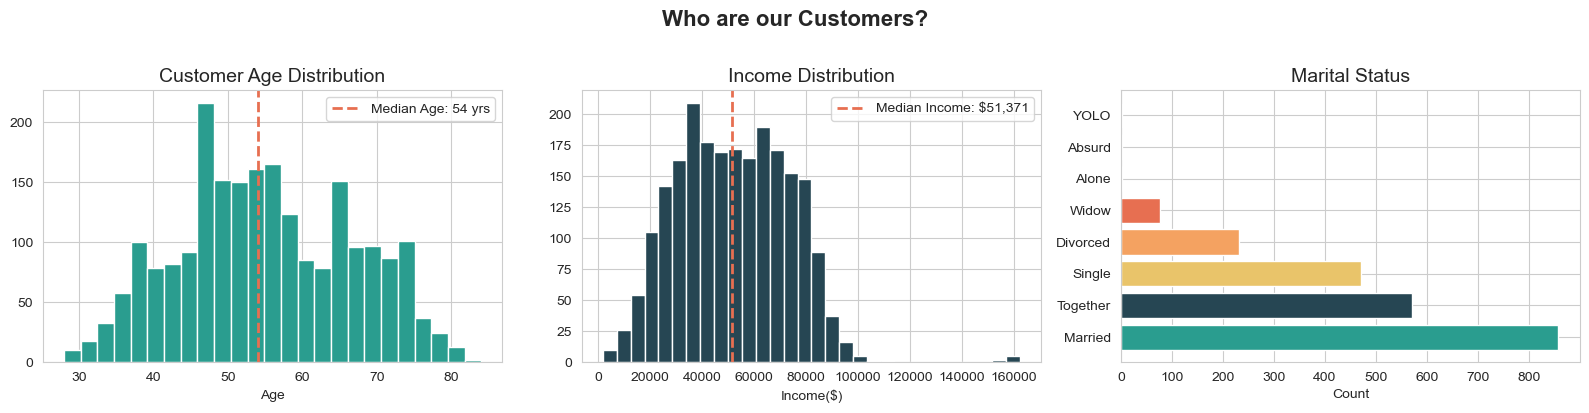

 📌 Median Age: 54 yrs | Median Income: 51,371
 📌 Most Common Marital Status: Married (857 customers)


In [14]:
# Customer demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

COLORS = ['#2a9d8f','#264653','#e9c46a','#f4a261','#e76f51','#a8dadc']
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Age Plot
axes[0].hist(customer_df['Age'], bins=25, color = COLORS[0], edgecolor ='white')
axes[0].axvline(customer_df['Age'].median(), color = COLORS[4], linestyle = '--', linewidth = 2, 
                label = (f"Median Age: {customer_df['Age'].median():,.0f} yrs"))
axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

# Income Plot
axes[1].hist(customer_df['Income'], bins=30, color = COLORS[1], edgecolor ='white')
axes[1].axvline(customer_df['Income'].median(), color = COLORS[4], linestyle = '--', linewidth = 2, 
                label = (f"Median Income: ${customer_df['Income'].median():,.0f}"))
axes[1].set_title("Income Distribution")
axes[1].set_xlabel("Income($)")
axes[1].legend()

# Marital Status Plot
marital = customer_df['Marital_Status'].value_counts()
axes[2].barh(marital.index, marital.values, color = COLORS)
axes[2].set_title("Marital Status")
axes[2].set_xlabel("Count")

plt.suptitle("Who are our Customers?", fontsize=16, fontweight= 'bold', y=1.02)
plt.tight_layout()
plt.show()

print(f" 📌 Median Age: {customer_df['Age'].median():.0f} yrs | Median Income: {customer_df['Income'].median():,.0f}")
print(f" 📌 Most Common Marital Status: {marital.index[0]} ({marital.iloc[0]:,} customers)")

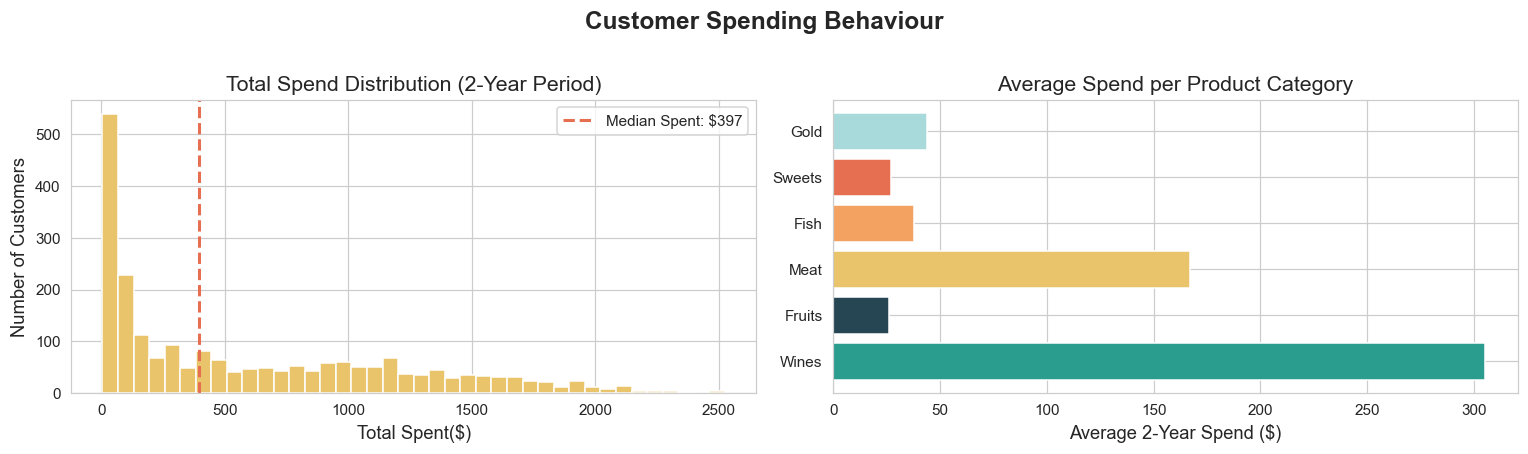

📌 Wines account for 50.3% of all spending - by far the biggest category.


In [15]:
# How much are customers spending?
fig, axes = plt.subplots(1, 2, figsize=(14,4))

# Total spent distribution
axes[0].hist(customer_df['Total_Spent'], bins=40, color = COLORS[2], edgecolor = 'white')
axes[0].axvline(customer_df['Total_Spent'].median(), color = COLORS[4], linestyle = '--', linewidth = 2, 
                label = (f"Median Spent: ${customer_df['Total_Spent'].median():,.0f}"))
axes[0].set_title("Total Spend Distribution (2-Year Period)")
axes[0].set_xlabel("Total Spent($)")
axes[0].set_ylabel("Number of Customers")
axes[0].legend()

# Average spent per category
cat_labels = ['Wines','Fruits','Meat','Fish','Sweets','Gold']
category_columns = ['MntWines', 'MntFruits','MntMeatProducts',
                         'MntFishProducts', 'MntSweetProducts','MntGoldProds']
cat_means = customer_df[category_columns].mean()
axes[1].barh(cat_labels, cat_means.values, color = COLORS, edgecolor='white')
axes[1].set_title("Average Spend per Product Category")
axes[1].set_xlabel("Average 2-Year Spend ($)")

plt.suptitle("Customer Spending Behaviour", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

wine_pct = customer_df['MntWines'].sum() / customer_df['Total_Spent'].sum() *100
print(f"📌 Wines account for {wine_pct:.1f}% of all spending - by far the biggest category.")

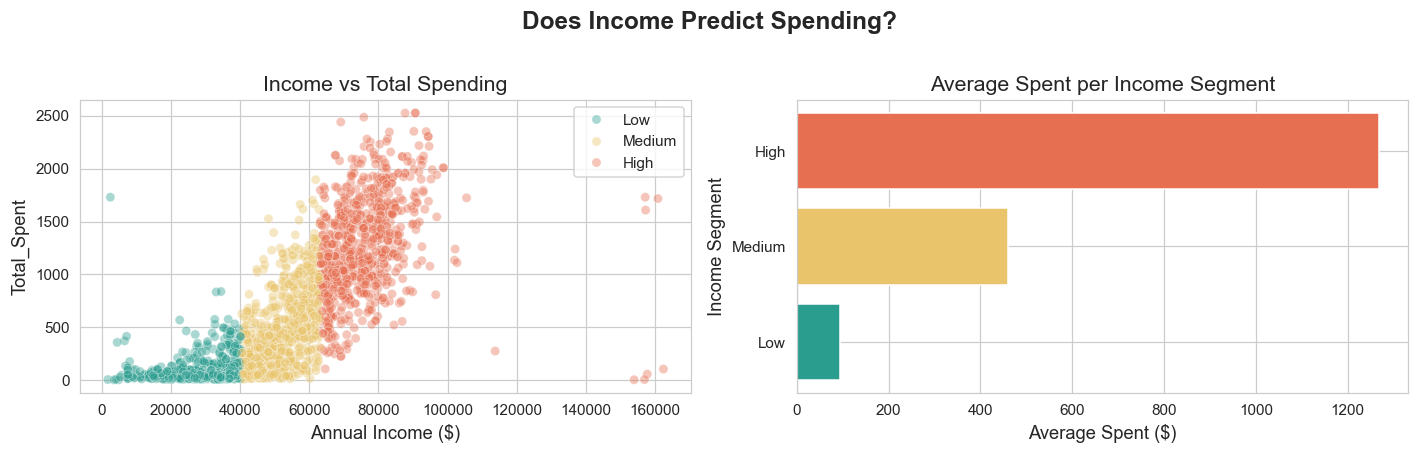

📌 Pearson Correlation (Income vs Spending) r = 0.793
📌 High positive correlation -- high income customers spend significantly more


In [16]:
# Does Income predict Spending?
income_spent = customer_df.groupby('Income_Segment', observed=True)['Total_Spent'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13,4))

# Scatter Plot
sns.scatterplot(customer_df, x='Income', y='Total_Spent', hue='Income_Segment', palette= (COLORS[0],COLORS[2],COLORS[4]), ax=axes[0], alpha=0.4)
axes[0].set_title('Income vs Total Spending')
axes[0].set_xlabel('Annual Income ($)')
axes[0].legend(title='Income Segment')
axes[0].legend()

# Bar Plot
axes[1].barh(income_spent['Income_Segment'], income_spent['Total_Spent'], color = [COLORS[0],COLORS[2],COLORS[4]], edgecolor= 'white')
axes[1].set_title('Average Spent per Income Segment')
axes[1].set_xlabel('Average Spent ($)')
axes[1].set_ylabel('Income Segment')

plt.suptitle("Does Income Predict Spending?", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

r = customer_df['Income'].corr(customer_df['Total_Spent'])
print(f"📌 Pearson Correlation (Income vs Spending) r = {r:.3f}")
print(f"📌 High positive correlation -- high income customers spend significantly more") 

In [17]:
# Campaign conversion rates overall
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
campaign_conversion_df = customer_df.melt(value_vars = campaign_cols, var_name = 'Campaign', value_name = 'Accepted')

conversion_summary = campaign_conversion_df.groupby('Campaign').agg(
    Converted = ('Accepted','sum'),
    Total = ('Accepted','count')).reset_index()
conversion_summary['Conversion_Rate'] = ((conversion_summary['Converted'] / conversion_summary['Total']) *100.0).round(2)

campaign_mapping = {
    'AcceptedCmp1': 'Reactivation Drive',
    'AcceptedCmp2': 'New Arrivals Push',
    'AcceptedCmp3': 'Seasonal Promotion',
    'AcceptedCmp4': 'Loyalty Reward',
    'AcceptedCmp5': 'Premium Upsell'
}

conversion_summary['Campaign'] = conversion_summary['Campaign'].map(campaign_mapping)
conversion_summary.sort_values(by='Conversion_Rate', ascending=True, inplace=True)
conversion_summary

,Campaign,Converted,Total,Conversion_Rate
1,New Arrivals Push,30,2212,1.36
0,Reactivation Drive,142,2212,6.42
4,Premium Upsell,161,2212,7.28
2,Seasonal Promotion,163,2212,7.37
3,Loyalty Reward,164,2212,7.41


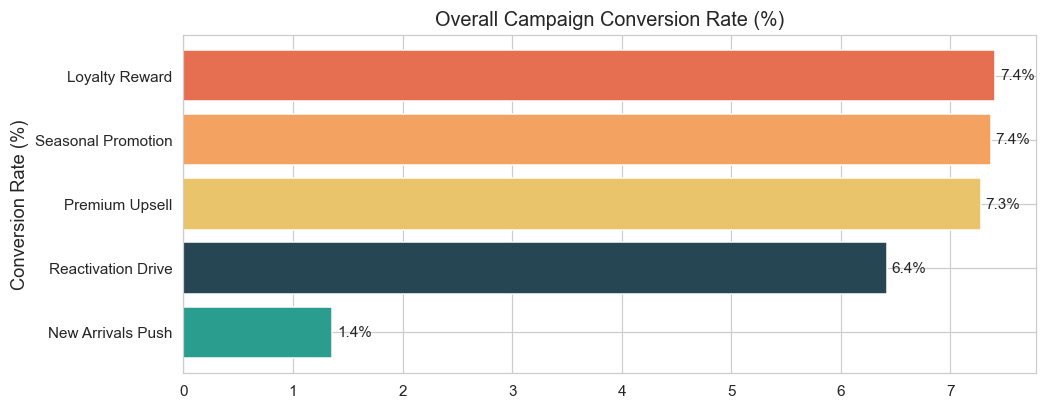

📌 Best Campaign: Loyalty Reward (7.4%) conversion
📌 Worst Campaign: New Arrivals Push (1.4%) conversion
📌 Campaign 2 (New Arrival Push) is under-performing , with barely 1% conversion across all customers


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
bar = ax.barh(conversion_summary['Campaign'], conversion_summary['Conversion_Rate'],
        color= COLORS, edgecolor ='white')
ax.bar_label(bar, fmt='%.1f%%', padding=3)
ax.set_title("Overall Campaign Conversion Rate (%)", fontsize=13)
ax.set_ylabel("Conversion Rate (%)")
plt.show()

best_camp = conversion_summary['Campaign'].iloc[-1]
worst_camp = conversion_summary['Campaign'].iloc[0]

print(f"📌 Best Campaign: {best_camp} ({conversion_summary['Conversion_Rate'].max():.1f}%) conversion")
print(f"📌 Worst Campaign: {worst_camp} ({conversion_summary['Conversion_Rate'].min():.1f}%) conversion")
print("📌 Campaign 2 (New Arrival Push) is under-performing , with barely 1% conversion across all customers")

---

## 👥 Step 5: RFM Segmentation

### What is RFM?

RFM is a behaviour based framework used by retail, e-commerce and subscription companies worldwide. Instead of guessing who your customers are, it uses actual purchase behaviour. 

| Letter | Stands for | The question it answer | why it matters |
|--------|------------|------------------------|----------------|
| **R** | Recency | How recently did the customer buy? | Recent buyers are more likely to buy again |
| **F** | Frequency | How many times did they buy? | Frequent buyers are more engaged and loyal |
| **M** | Monetary | How much did they spend? | High spenders drives the most revenue |

**How scoring works:**
- Each customer gets a score between 1-5 on each dimension
- For Recency **lower days = good = higher score** (bought yesterday - score = 5, bought 1 year ago - score = 1)
- For Frequency & Moneatry **high quantity or high spending = higher score**

In [19]:
rfm = customer_df[['ID','Recency','Total_Purchases','Total_Spent']].copy()
rfm.columns = ['ID','Recency','Frequency','Monetary']
rfm.describe().round(1)

,ID,Recency,Frequency,Monetary
count,2212.0,2212.0,2212.0,2212.0
mean,5585.2,49.0,20.2,607.3
std,3247.5,28.9,7.3,602.5
min,0.0,0.0,0.0,5.0
25%,2814.8,24.0,14.0,69.0
50%,5454.5,49.0,19.0,397.0
75%,8418.5,74.0,25.0,1048.0
max,11191.0,99.0,46.0,2525.0


In [20]:
# Score each dimension
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm.head()

,ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,5524,58,32,1617,3,5,5
1,2174,38,11,27,4,1,1
2,4141,26,25,776,4,4,4
3,6182,26,14,53,4,2,1
4,5324,94,24,422,1,4,3


In [21]:
# Assign customer segments
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'

    elif r == 1 and f >= 3:
        return 'At Risk'

    elif m >= 4:
        return 'Big Spenders'

    elif r <= 2 and f <= 2:
        return 'Hibernating'

    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis = 1)
rfm.head()

,ID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,5524,58,32,1617,3,5,5,Loyal Customers
1,2174,38,11,27,4,1,1,Needs Attention
2,4141,26,25,776,4,4,4,Champions
3,6182,26,14,53,4,2,1,Needs Attention
4,5324,94,24,422,1,4,3,At Risk


In [22]:
# Segment Summary
segment_summary = (rfm.groupby('Segment')
                   .agg( Customers = ('ID','count'),
                         Avg_Recency = ('Recency','mean'),
                         Avg_Frequency = ('Frequency','mean'),
                         Avg_Spend = ('Monetary','mean'),
                         Total_Revenue = ('Monetary','sum'))
                   .round(1)
                   .sort_values('Total_Revenue', ascending = False)
                   .reset_index())

segment_summary['Revenue_Share_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() *100).round(1)
segment_summary['Customer_Share_%'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() *100).round(1)

print('*----------Segment Summary----------*')
segment_summary

*----------Segment Summary----------*


,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Spend,Total_Revenue,Revenue_Share_%,Customer_Share_%
0,Loyal Customers,472,33.7,24.0,872.0,411576,30.6,21.3
1,Big Spenders,234,64.4,23.3,1253.9,293414,21.8,10.6
2,Champions,247,19.1,28.8,1177.2,290780,21.6,11.2
3,At Risk,254,89.5,25.2,945.7,240210,17.9,11.5
4,Needs Attention,670,34.7,15.0,119.8,80235,6.0,30.3
5,Hibernating,335,79.8,13.1,80.8,27062,2.0,15.1


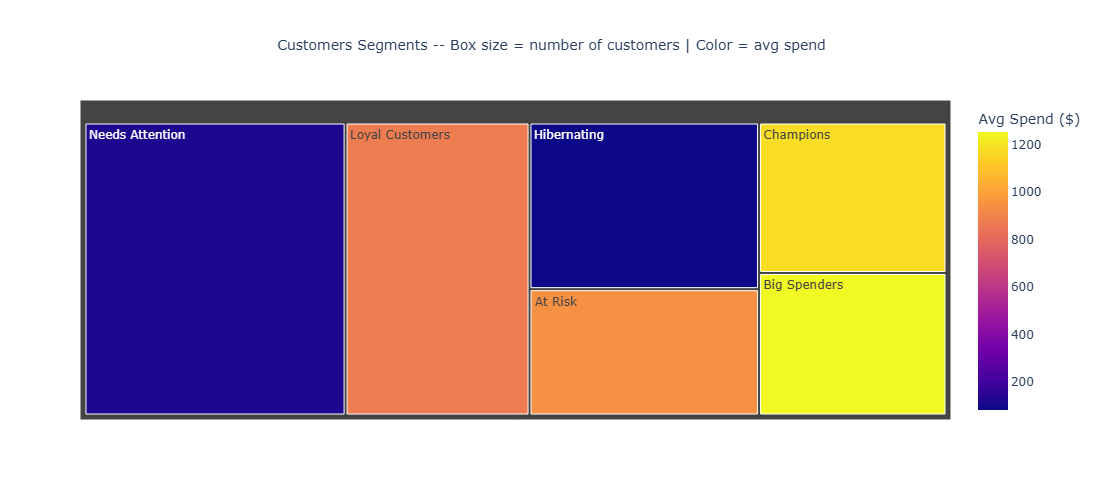

In [23]:
# Visualize the segment
fig = px.treemap(segment_summary,
                 path = ['Segment'],
                 values = 'Customers',
                 color = 'Avg_Spend',
                 color_continuous_scale = 'Plasma',
                 custom_data = ['Revenue_Share_%','Customer_Share_%','Avg_Recency',	'Avg_Frequency'],
                 title = 'Customers Segments -- Box size = number of customers | Color = avg spend')

fig.update_traces(
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Customers      : %{value:,}<br>'
        'Customer Share : %{customdata[1]:.1f}%<br>'
        'Revenue Share  : %{customdata[0]:.1f}%<br>'
        'Avg Spend      : $%{color:,.0f}<br>'
        'Avg Recency    : %{customdata[2]:.0f} days<br>'
        'Avg Frequency  : %{customdata[3]:.1f} purchases<br>'
        '<extra></extra>'
    )
)
fig.update_layout(title_font_size=14, title_x=0.5, height=500,
                  coloraxis_colorbar=dict(title='Avg Spend ($)'))
fig.show()

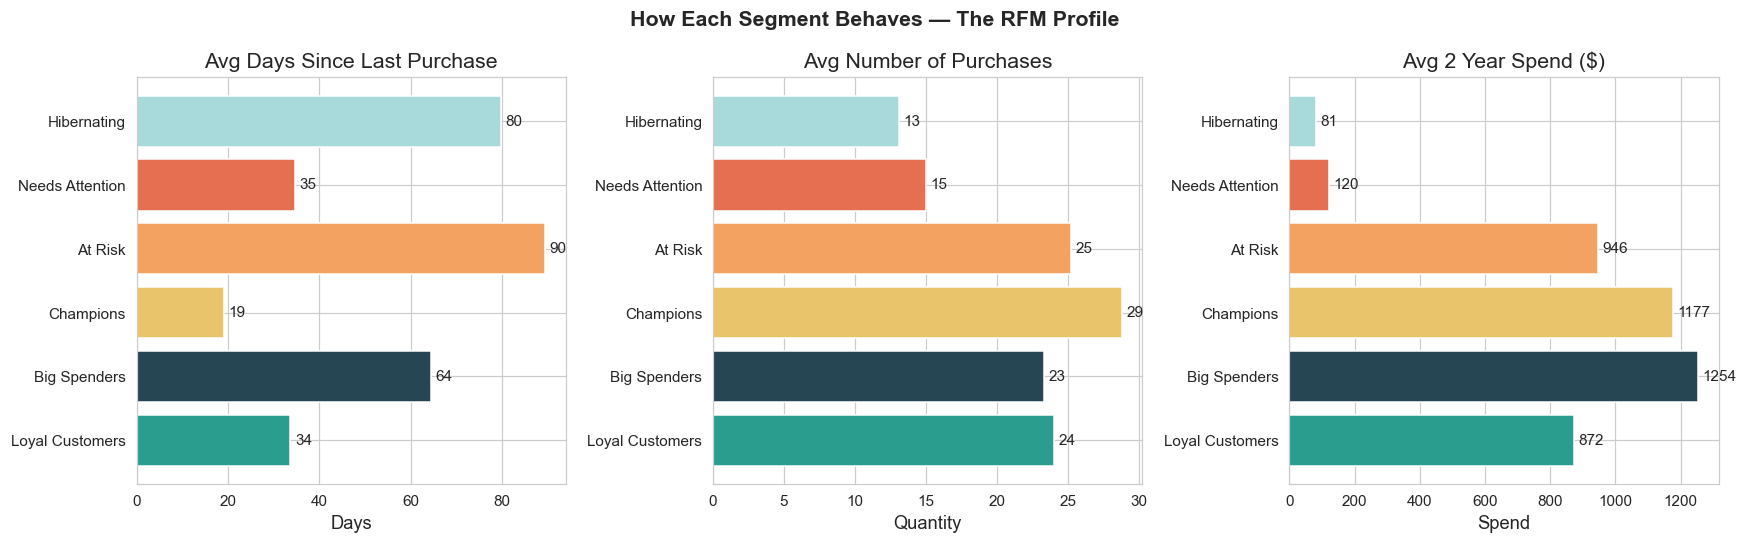

In [24]:
# RFM profile bar charts
fig, axes = plt.subplots(1, 3, figsize=(16,5))

bars0 = axes[0].barh(segment_summary['Segment'], segment_summary['Avg_Recency'], color = COLORS, edgecolor = 'white')
axes[0].bar_label(bars0, fmt='%.0f', padding=3)
axes[0].set_title('Avg Days Since Last Purchase')
axes[0].set_xlabel('Days')

bars1 = axes[1].barh(segment_summary['Segment'], segment_summary['Avg_Frequency'], color = COLORS, edgecolor = 'white')
axes[1].bar_label(bars1, fmt='%.0f', padding=3)
axes[1].set_title('Avg Number of Purchases')
axes[1].set_xlabel('Quantity')

bars2 = axes[2].barh(segment_summary['Segment'], segment_summary['Avg_Spend'], color = COLORS, edgecolor = 'white')
axes[2].bar_label(bars2, fmt='%.0f', padding=3)
axes[2].set_title('Avg 2 Year Spend ($)')
axes[2].set_xlabel('Spend')

plt.suptitle("How Each Segment Behaves — The RFM Profile", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛡️ STEP 6: Validating the Segments

> A good segmentation isn't about just the labelling customers -- we need to prove the segments are **genuinely different** from each other and not just random groups.

I'll use two validation methods:
1. **ANOVA test** : a statistical test to confirm spending differences between the segments are real, not due to chance.
2. **K-Means clustering** : an independent unsupervised ML method to cross-check our rule-based segments.

In [25]:
# ANOVA test
# Is there a real difference between avg spending across segments,or just noise.

from scipy import stats

groups = [grp['Monetary'].values for _, grp in rfm.groupby('Segment')]
f_stat, p_value = stats.f_oneway(*groups)

print("---------- One-way ANOVA : Monetary Value across segments ----------")
print(f"F_Statistic    : {f_stat:.2f}")
print(f"P_Value        : {p_value:.2f}")

print()
if p_value < 0.05:
    print("✅ RESULT -- the spending differences between the segments is STATISTICALLY SIGNIFICANT")
    print("(p < 0.05 means there's less than a 5% chance these differences happened by luck.)")
    print("The segments represent genuinely distinct customer groups.")
else:
    print("⚠️ RESULT: Differences are NOT significant at α=0.05.")


---------- One-way ANOVA : Monetary Value across segments ----------
F_Statistic    : 700.08
P_Value        : 0.00

✅ RESULT -- the spending differences between the segments is STATISTICALLY SIGNIFICANT
(p < 0.05 means there's less than a 5% chance these differences happened by luck.)
The segments represent genuinely distinct customer groups.


## 📣 Step 7 — Campaign Conversion Analysis by Segment

> Now we answer the key marketing question -- **Which campaign works for which customer?**

> We use **conversion rates (%)** rather than raw counts, because a small segment with 40% conversion rate is far more valuable to understand than a large one with 5%

In [26]:
# Merge segment labels into main dataframe
customer_df = customer_df.merge(rfm[['ID','Segment']], on='ID', how='left')

# Rename campaigns to friendly names for charts
CAMP_MAP = {
    'AcceptedCmp1': 'Cmp1 Reactivation',
    'AcceptedCmp2': 'Cmp2 New Arrivals',
    'AcceptedCmp3': 'Cmp3 Seasonal',
    'AcceptedCmp4': 'Cmp4 Loyalty',
    'AcceptedCmp5': 'Cmp5 Premium Upsell'
}

camp_rates = (customer_df.groupby('Segment')[list(CAMP_MAP.keys())]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns=CAMP_MAP))

print('----Campaign Conversion Rate (%) by segment----')
print('What % of customers in each segment converted on each campaign')
camp_rates

----Campaign Conversion Rate (%) by segment----
What % of customers in each segment converted on each campaign


,Cmp1 Reactivation,Cmp2 New Arrivals,Cmp3 Seasonal,Cmp4 Loyalty,Cmp5 Premium Upsell
Segment,,,,,
At Risk,8.3,2.0,9.1,12.2,11.4
Big Spenders,15.4,4.3,6.0,15.4,19.7
Champions,16.6,2.4,12.1,12.6,15.0
Hibernating,0.0,0.0,3.6,1.5,0.0
Loyal Customers,9.3,1.5,6.6,11.0,10.4
Needs Attention,0.0,0.3,7.9,1.3,0.0


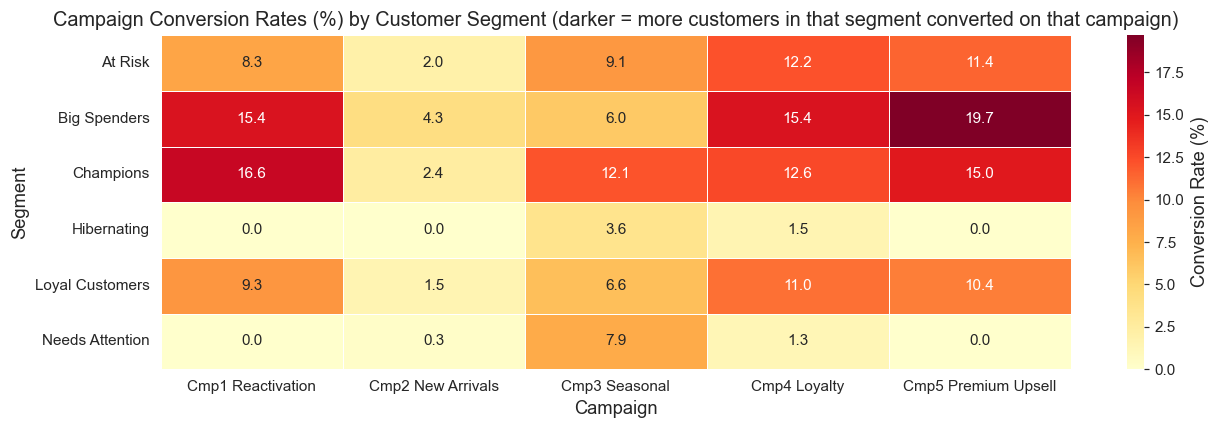

📌 Dark red = campaign resonated strongly with that segment
📌 Light/white = campaign had little impact on that segment


In [27]:
fig, ax = plt.subplots(figsize =(12,4))
sns.heatmap(camp_rates, annot =True, fmt='.1f', cmap='YlOrRd',
           linewidths=0.5, cbar_kws= {'label': 'Conversion Rate (%)'} , ax=ax, vmin=0)
ax.set_title("Campaign Conversion Rates (%) by Customer Segment (darker = more customers in that segment converted on that campaign)",
             fontsize=13)
ax.set_xlabel("Campaign")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.show()

print("📌 Dark red = campaign resonated strongly with that segment")
print("📌 Light/white = campaign had little impact on that segment")

In [30]:
camp_counts.reset_index()

,Segment,Cmp1 Reactivation,Cmp2 New Arrivals,Cmp3 Seasonal,Cmp4 Loyalty,Cmp5 Premium Upsell
0,At Risk,21,5,23,31,29
1,Big Spenders,36,10,14,36,46
2,Champions,41,6,30,31,37
3,Hibernating,0,0,12,5,0
4,Loyal Customers,44,7,31,52,49
5,Needs Attention,0,2,53,9,0


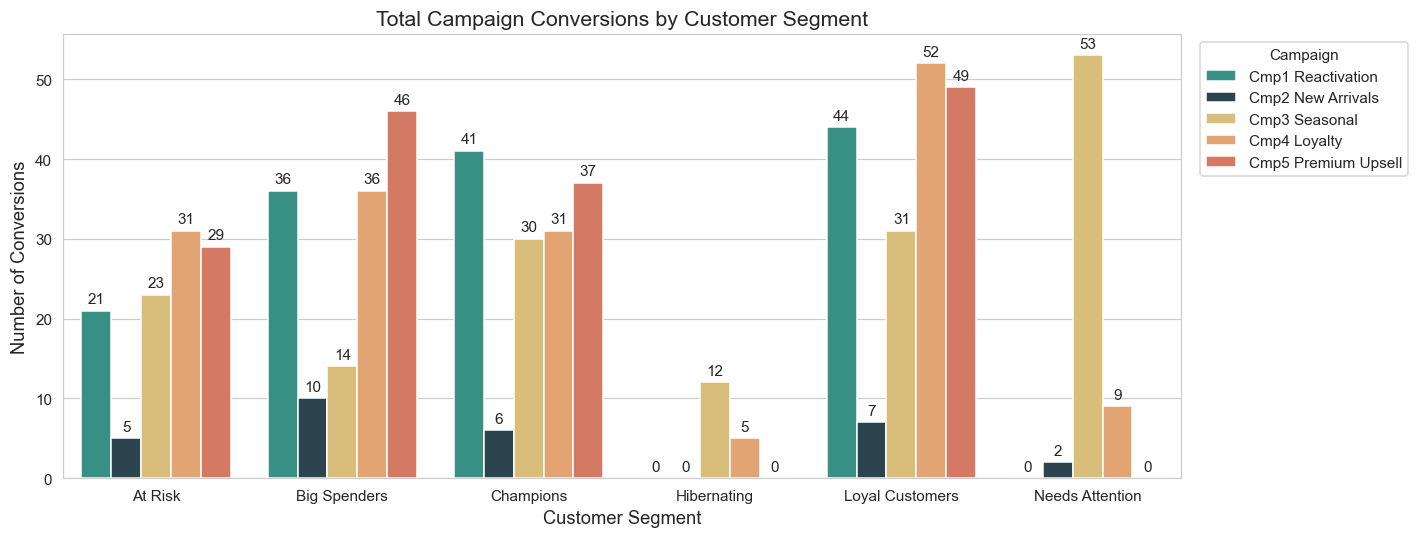

In [57]:
# Campaign Response by segment
camp_counts = (customer_df.groupby('Segment')[list(CAMP_MAP.keys())]
               .sum()
               .rename(columns=CAMP_MAP))
camp_long = camp_counts.reset_index().melt(id_vars = 'Segment',var_name = 'Campaign',value_name = 'Conversions').reset_index()

plt.figure(figsize=(13, 5))
ax = sns.barplot(camp_long, x = 'Segment', y ='Conversions', hue ='Campaign',palette =COLORS[:5])
# Add labels to every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title("Total Campaign Conversions by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Conversions")
plt.legend(title='Campaign', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

--- 
## 💰 STEP 8: Revenue & Customer Distribution by Segment

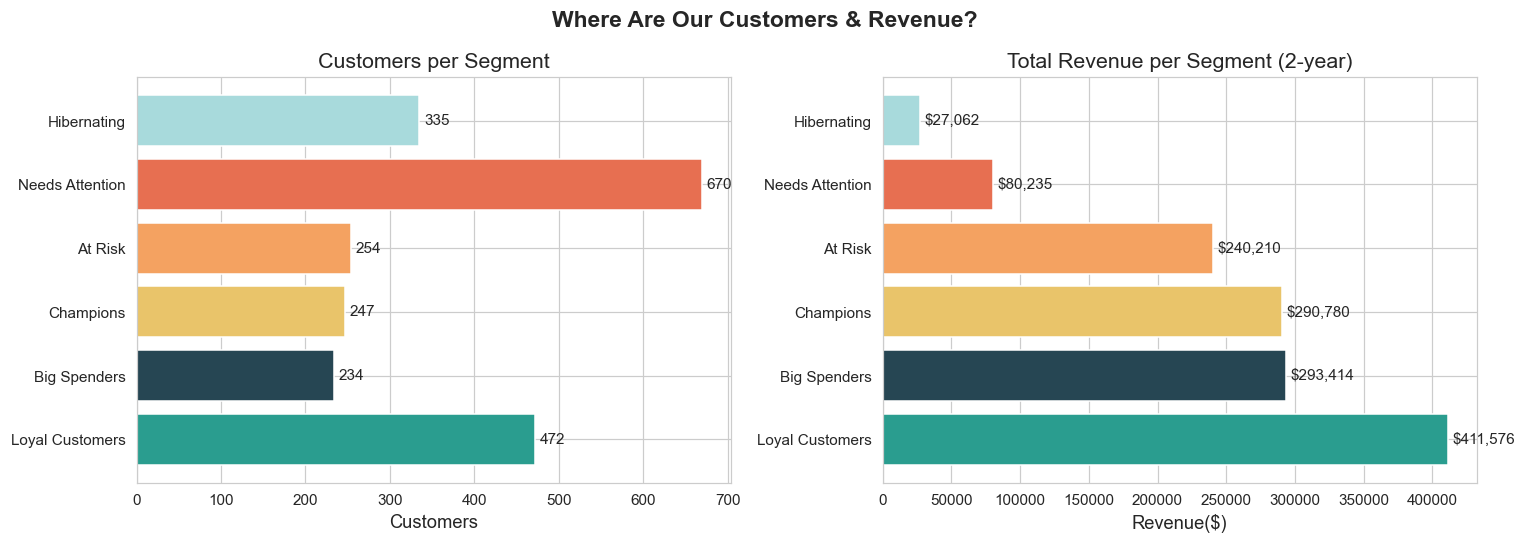

In [60]:
# Customer count and revenue by segment

fig, axes = plt.subplots(1,2, figsize=(14,5))

# customer count 
bars0 = axes[0].barh(segment_summary['Segment'], segment_summary['Customers'], color = COLORS, edgecolor = 'white')
axes[0].bar_label(bars0, fmt='%.0f', padding=3)
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Customers')

# segment revenue
bars1 = axes[1].barh(segment_summary['Segment'], segment_summary['Total_Revenue'], color = COLORS, edgecolor = 'white')
labels = [f'${x:,.0f}' for x in segment_summary['Total_Revenue']]
axes[1].bar_label(bars1,labels= labels, fmt='$%.0f', padding=3)
axes[1].set_title('Total Revenue per Segment (2-year)')
axes[1].set_xlabel('Revenue($)')

plt.suptitle("Where Are Our Customers & Revenue?", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💡 STEP 9: Recommendations

In [82]:
display(
    segment_summary[['Segment','Customers','Total_Revenue','Revenue_Share_%','Avg_Spend','Avg_Recency']].style
    .format({
        'Total_Revenue': '${:,.0f}',
        'Revenue_Share_%':'{:.0f}%',
        'Avg_Spend': '${:,.0f}',
        'Avg_Recency': '{:.0f} days'
    })
    .background_gradient(cmap='Blues', subset=['Total_Revenue'])
    .set_caption("Customer Segment Summary")
    .hide(axis='index')
)

Segment,Customers,Total_Revenue,Revenue_Share_%,Avg_Spend,Avg_Recency
Loyal Customers,472,"$411,576",31%,$872,34 days
Big Spenders,234,"$293,414",22%,"$1,254",64 days
Champions,247,"$290,780",22%,"$1,177",19 days
At Risk,254,"$240,210",18%,$946,90 days
Needs Attention,670,"$80,235",6%,$120,35 days
Hibernating,335,"$27,062",2%,$81,80 days


---
### 💡 Recommendation 1 — Protect Champions with the Premium Upsell (Campaign 5)

**Segment:** Champions  
**Observation:** Champions have the highest individual spend and the strongest Campaign 5 (Premium Upsell) conversion rate. They are our most valuable customers and most at risk of being under-served.

**Action:** Run Campaign 5 (Premium Upsell) exclusively for Champions each quarter. Introduce a VIP tier with early access and free shipping.

**Revenue estimate:**
- Champions generate ~20–25% of total revenue
- A 10% increase in their average spend through upsells → **estimated +$30K–$45K per year**
- Retaining just 5% of Champions who might lapse → avoids **~$15K–$25K revenue loss**

---

### 💡 Recommendation 2 — Re-engage At Risk Customers Immediately (Campaign 1)

**Segment:** At Risk  
**Observation:** At Risk customers were historically high-value (strong Frequency + Monetary) but haven't bought recently. Campaign 1 (Reactivation Drive) has the best conversion rate in this group.

**Action:** Launch a personalised win-back email within 30 days. Offer a 15–20% discount with a deadline (e.g. "Your offer expires in 7 days"). After 60 days of no response, move to low-cost drip.

**Revenue estimate:**
- At Risk segment holds ~$250K in historical spend
- Re-engaging 20% at their historical average → **estimated +$50K–$70K recovered revenue**
- Cost of inaction: full churn of At Risk = **loss of ~$250K+ in lifetime value**

---

### 💡 Recommendation 3 — Deepen Loyalty Rewards (Campaign 4)

**Segment:** Loyal Customers  
**Observation:** Loyal Customers generate the most total revenue of any segment and respond well to Campaign 4 (Loyalty Reward). They are already engaged — the goal is to increase frequency.

**Action:** Run Campaign 4 with a tiered rewards structure (e.g. spend $200 → earn $20 credit). Add a referral element — loyal customers are our best word-of-mouth channel.

**Revenue estimate:**
- A 15% increase in Loyal Customer purchase frequency → **estimated +$60K–$90K additional revenue**
- A 5% referral rate = ~20–30 new mid-value customers

---

### 💡 Recommendation 4 — Convert Promising Customers (Campaign 3)

**Segment:** Promising  
**Observation:** Promising customers bought recently but haven't returned often. Campaign 3 (Seasonal Promotion) gives them a low-commitment reason to return.

**Action:** Target with Campaign 3 during the next seasonal peak. Follow up 30 days later with Campaign 4 to begin building loyalty habits.

**Revenue estimate:**
- 30% of Promising customers making a second purchase at average spend → **estimated +$20K–$35K incremental revenue**

---

### 💡 Recommendation 5 — Pause Campaign 2 and Reallocate Budget

**Finding:** Campaign 2 (New Arrivals Push) has the lowest conversion rate across ALL segments — consistently under 2%. It is underperforming by 3–5× compared to other campaigns.

**Action:** Pause Campaign 2. Reallocate that budget to Campaigns 1 and 4 which show the strongest results. If kept, redesign with A/B testing.

**Revenue estimate:**
- Reallocating Campaign 2 budget to Campaign 4: **estimated 1.5–2× ROI improvement** on that budget

---

### 💡 Recommendation 6 — Low-cost Drip for Hibernating Customers

**Segment:** Hibernating  
**Observation:** Low engagement across the board. Not worth premium campaign budget — but a cheap automated email sequence can recover some.

**Action:** 3-email automated sequence over 6 weeks with a single compelling offer (e.g. "We miss you — 25% off your next order"). Archive after 3 failed attempts.

**Revenue estimate:**
- Even 5% reactivation at average spend → **estimated +$8K–$15K recovered revenue**  
- Cost: near-zero (automated email only)
